# Logistic Regression - Fraud Detection

##  Imports

This notebook uses pandas and numpy for data manipulation, matplotlib and seaborn for visualization, imblearn for addressing class imbalance, and scikit-learn for preprocessing, modeling, and evaluation. Given the severe class imbalance inherent to fraud detection, a broad set of evaluation metrics is imported upfront, since accuracy alone is not a reliable measure of model performance in this context.

In [1]:
# Imports
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score, roc_curve, roc_auc_score, precision_recall_curve, average_precision_score

## 1. Load Data

Three source tables are loaded: transactions, cards, and users, along with a merchant category code (MCC) lookup. Fraud labels are provided separately as a nested JSON object and are extracted into a standalone DataFrame before being merged onto the transactions table by `id`, producing the base dataset used throughout the rest of the notebook.

In [2]:
# Part 1: Load the data

# Main files
df_cards = pd.read_csv("data/cards_data.csv")
df_users = pd.read_csv("data/users_data.csv")
df_transactions = pd.read_csv("data/transactions_data.csv")

# load the merchant category codes
with open("data/mcc_codes.json") as file:
    mcc_codes = json.load(file)

# Load the fraud labels
with open("data/train_fraud_labels.json") as file:
    labels = json.load(file)["target"]  # extract the nested dict

# Merge the transactions dataset with the fraud labels
labels_df = pd.Series(labels, name = "fraud_label").reset_index()
labels_df.columns = ["id", "fraud_label"]
labels_df["id"] = labels_df["id"].astype(int)

df = df_transactions.merge(labels_df, on = "id")
df.head()

,id,date,client_id,card_id,amount,use_chip,merchant_id,merchant_city,merchant_state,zip,mcc,errors,fraud_label
0,7475327,2010-01-01 00:01:00,1556,2972,$-77.00,Swipe Transaction,59935,Beulah,ND,58523.0,5499,NaN,No
1,7475328,2010-01-01 00:02:00,561,4575,$14.57,Swipe Transaction,67570,Bettendorf,IA,52722.0,5311,NaN,No
2,7475329,2010-01-01 00:02:00,1129,102,$80.00,Swipe Transaction,27092,Vista,CA,92084.0,4829,NaN,No
3,7475332,2010-01-01 00:06:00,848,3915,$46.41,Swipe Transaction,13051,Harwood,MD,20776.0,5813,NaN,No
4,7475333,2010-01-01 00:07:00,1807,165,$4.81,Swipe Transaction,20519,Bronx,NY,10464.0,5942,NaN,No


## 2. Exploratory Data Analysis

This section examines the dataset's structure, class balance, and candidate features prior to any modeling. Several features hypothesized to be predictive of fraud (e.g., account age, PIN recency, cardholder age) are evaluated directly against observed fraud rates rather than assumed to be informative, and are retained or excluded based on that evidence.


In [3]:
# Part 2: EDA

# General Info and Shape of the dataset
print(df.dtypes)
print()
print(df.isnull().sum())
print()
print(df.shape)

id                  int64
date                  str
client_id           int64
card_id             int64
amount                str
use_chip              str
merchant_id         int64
merchant_city         str
merchant_state        str
zip               float64
mcc                 int64
errors                str
fraud_label           str
dtype: object

id                      0
date                    0
client_id               0
card_id                 0
amount                  0
use_chip                0
merchant_id             0
merchant_city           0
merchant_state    1047865
zip               1107377
mcc                     0
errors            8773196
fraud_label             0
dtype: int64

(8914963, 13)


### Class Distribution

This is the foundational statistic for the analysis: the proportion of transactions labeled as fraudulent. This distribution informs the choice of evaluation metrics, the class imbalance strategy applied later, and how model accuracy should be interpreted (a model predicting the majority class exclusively would still achieve high accuracy).

fraud_label
No     8901631
Yes      13332
Name: count, dtype: int64


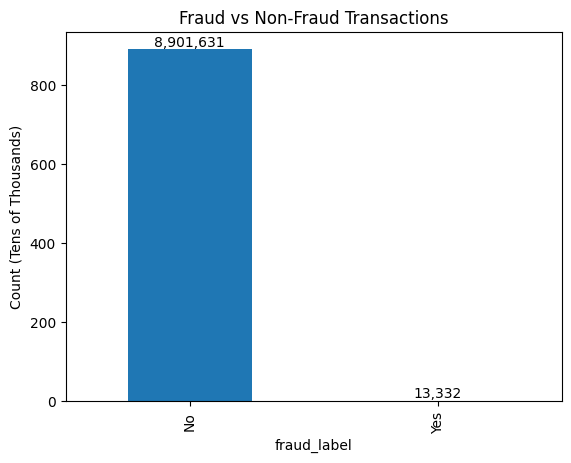

In [4]:
# Plot the class distribution
print(df["fraud_label"].value_counts())
fraud_counts = df["fraud_label"].value_counts()

ax = fraud_counts.plot(kind = "bar")
ax.set_title("Fraud vs Non-Fraud Transactions")
ax.set_ylabel("Count (Tens of Thousands)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x / 10000)}"))

for p in ax.patches:
    ax.annotate(f"{int(p.get_height()):,}", (p.get_x() + p.get_width() / 2., p.get_height()), ha = "center", va = "bottom")

plt.show()

### Transaction Amount Distribution

A standard histogram of transaction amounts is not informative here, as the distribution is heavily right-skewed, with the overwhelming majority of values concentrated near zero and a small number of high-value outliers extending the range considerably. A binned frequency table is used instead, providing exact counts and percentages without the visual distortion caused by the skew.

In [5]:
# Create a table for the transaction amount distribution
df["amount_range"] = df["amount"].str.replace("$", "", regex = False).astype(float)

bins = [-np.inf, 0, 10, 25, 50, 100, 250, 500, 1000, 2000, 5000, np.inf]
labels = ["<$0", "$0-10", "$10-25", "$25-50", "$50-100", "$100-250",
          "$250-500", "$500-1000", "$1000-2000", "$2000-5000", "$5000+"]

amount_table = pd.cut(df["amount_range"], bins = bins, labels = labels).value_counts().sort_index()
amount_table = amount_table.rename("Count").to_frame()
amount_table["%"] = (amount_table["Count"] / len(df) * 100).round(2)
amount_table

,Count,%
amount_range,,
<$0,449972,5.05
$0-10,1947741,21.85
$10-25,1735234,19.46
$25-50,1802739,20.22
$50-100,2021073,22.67
$100-250,821487,9.21
$250-500,107855,1.21
$500-1000,22733,0.25
$1000-2000,5905,0.07


### Fraud Rate by Amount Bucket

Building on the amount distribution above, this analysis examines whether fraud rate varies by transaction amount. The data show a clear, non-linear relationship: fraud rate remains low and relatively stable below approximately $250, then increases sharply, exceeding 12% in the $2,000 – $5,000 range. This relationship is later incorporated into the feature set.

In [6]:
# Create a table for the transaction amount distribution grouped by fraud label
fraud_amount_table = (
    df.groupby(pd.cut(df["amount_range"], bins = bins, labels = labels))["fraud_label"]
    .value_counts()
    .unstack(fill_value = 0)
    .rename(columns = {"Yes": "fraud_count", "No": "non_fraud_count"})
)

fraud_amount_table["total"] = fraud_amount_table["fraud_count"] + fraud_amount_table["non_fraud_count"]
fraud_amount_table["fraud_rate(%)"] = (
    fraud_amount_table["fraud_count"] / fraud_amount_table["total"] * 100
).round(3)

fraud_amount_table

fraud_label,non_fraud_count,fraud_count,total,fraud_rate(%)
amount_range,,,,
<$0,449477,495,449972,0.110
$0-10,1945616,2125,1947741,0.109
$10-25,1734023,1211,1735234,0.070
$25-50,1801137,1602,1802739,0.089
$50-100,2018255,2818,2021073,0.139
$100-250,817973,3514,821487,0.428
$250-500,106641,1214,107855,1.126
$500-1000,22480,253,22733,1.113
$1000-2000,5832,73,5905,1.236


### Log-Transforming Amount

Because transaction amount is heavily right-skewed, it is not well suited as a raw input to a linear model, where extreme values can disproportionately influence the fitted coefficients. A log transformation is applied to compress the distribution while preserving rank order. Negative amounts (refunds) are handled explicitly so the transformation remains well-defined across the full range of values.

In [7]:
# log-transform amount to handle skew + non-linear fraud relationship
# (reason: fraud rate table above shows fraud rate rises sharply above ~$250,
# raw amount is heavily right-skewed — log-transform compresses the tail before scaling)
df["amount_log"] = np.sign(df["amount_range"]) * np.log1p(np.abs(df["amount_range"]))

## 3. Preprocessing

This section combines the transaction, card, and user tables into a single model-ready dataset. Card and user features are merged in to provide additional context beyond the transaction itself; currency-formatted columns are cleaned; date fields are decomposed into usable components; and two engineered features, `had_error` and `mcc_risk_tier`, are constructed based on relationships identified during EDA. The pipeline then encodes categorical variables, performs a train/test split, scales numeric features, and applies SMOTE to the training set to address class imbalance.

**Note:** `mcc_risk_tier` is derived from fraud rates computed across the full dataset, including data that later becomes part of the test set. This constitutes a mild form of data leakage, which is acknowledged and discussed further in the Limitations subsection of the final section.


In [8]:
# Part 3: Preprocessing

# Parse the date
df["date"] = pd.to_datetime(df["date"])

# Merge the main card df with the card and user info
print("Before merge:", len(df))
df = df.merge(df_cards, left_on = "card_id", right_on = "id", suffixes = ("", "_card"))
df = df.merge(df_users, left_on = "client_id", right_on = "id", suffixes = ("", "_user"))
print("After merge:", len(df), "\n")

# Fix the currency-formatted columns from cards/users data
currency_cols = ["credit_limit", "yearly_income", "total_debt"]
for col in currency_cols:
    df[col] = df[col].astype(str).str.replace("$", "", regex=False).astype(float)

# Date-derived features
df["hour"] = df["date"].dt.hour
df["day_of_week"] = df["date"].dt.dayofweek
df["month"] = df["date"].dt.month

# Boolean flag for had_error
df["had_error"] = df["errors"].notnull().astype(int)

# Encode the target values
df["fraud_label"] = df["fraud_label"].map({"Yes": 1, "No": 0})

# mcc risk tier (based on observed fraud rate per mcc code)
mcc_fraud_rate = df.groupby("mcc")["fraud_label"].mean()
mcc_risk_tier_map = pd.qcut(mcc_fraud_rate, q = 3, labels = ["low_risk", "medium_risk", "high_risk"])
df["mcc_risk_tier"] = df["mcc"].map(mcc_risk_tier_map)

# Select the features to be used and encode the categoricals
cat_cols = ["use_chip", "card_brand", "card_type", "has_chip", "mcc_risk_tier"]
num_cols = ["amount_log", "hour", "day_of_week", "month", "had_error", "credit_limit", 
            "num_cards_issued", "credit_score", "total_debt", "num_credit_cards", "yearly_income"]

print("Before dropna:", len(df))
df = df.dropna(subset = num_cols)
print("After dropna:", len(df), "\n")

df = pd.get_dummies(df, columns = cat_cols, drop_first = True)

feature_cols = num_cols + [c for c in df.columns if any(c.startswith(cat + "_") for cat in cat_cols)]
print("The feature columns are:", feature_cols, "\n")

X = df[feature_cols]
y = df["fraud_label"]

# 80/20 split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)

# Scale the numeric features
scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

# Apply SMOTE to handle the class imbalance
smote = SMOTE(random_state = 42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("X_train_res shape:", X_train_res.shape)
print("y_train_res class balance:")
print(y_train_res.value_counts())

Before merge: 8914963
After merge: 8914963 

Before dropna: 8914963
After dropna: 8914963 

The feature columns are: ['amount_log', 'hour', 'day_of_week', 'month', 'had_error', 'credit_limit', 'num_cards_issued', 'credit_score', 'total_debt', 'num_credit_cards', 'yearly_income', 'use_chip_Online Transaction', 'use_chip_Swipe Transaction', 'card_brand_Discover', 'card_brand_Mastercard', 'card_brand_Visa', 'card_type_Debit', 'card_type_Debit (Prepaid)', 'has_chip_YES', 'mcc_risk_tier_medium_risk', 'mcc_risk_tier_high_risk'] 

X_train_res shape: (14242608, 21)
y_train_res class balance:
fraud_label
0    7121304
1    7121304
Name: count, dtype: int64


## 4. Model Training

Two logistic regression models are trained using identical features, differing only in how class imbalance is addressed: one is trained on SMOTE-resampled data, and the other is trained on the original, unresampled data using `class_weight = "balanced"`. Training both models under otherwise identical conditions allows for a direct comparison of these two imbalance-handling strategies.

In [9]:
# Step 4: Model Training 

# Model A: trained on SMOTE-resampled data
model_smote = LogisticRegression(max_iter = 1000, random_state = 42)
model_smote.fit(X_train_res, y_train_res)

y_pred_smote = model_smote.predict(X_test)
y_proba_smote = model_smote.predict_proba(X_test)[:, 1]

# Model B: trained on original (unresampled) data, using class_weight = "balanced"
model_balanced = LogisticRegression(max_iter = 1000, random_state = 42, class_weight = "balanced")
model_balanced.fit(X_train, y_train)

y_pred_balanced = model_balanced.predict(X_test)
y_proba_balanced = model_balanced.predict_proba(X_test)[:, 1]

## 5. Evaluation

Given the rarity of fraud in this dataset, accuracy alone is not a meaningful metric; a model that never predicts fraud would still achieve approximately 99.85% accuracy. Evaluation therefore focuses on precision, recall, and F1-score for the fraud class, as well as ROC-AUC and PR-AUC evaluated together, since these two metrics diverge meaningfully under severe class imbalance. A threshold-tuning analysis on the SMOTE model further illustrates the precision-recall tradeoff relative to the default 0.5 classification threshold.


=== Model A: SMOTE (threshold = 0.5) ===
              precision    recall  f1-score   support

           0       1.00      0.88      0.94   1780327
           1       0.01      0.75      0.02      2666

    accuracy                           0.88   1782993
   macro avg       0.50      0.82      0.48   1782993
weighted avg       1.00      0.88      0.94   1782993

Accuracy: 0.8833068890343372
F1 Score: 0.018973345843922542 

ROC-AUC:  0.8929819633415447
PR-AUC:  0.03104130531637941 



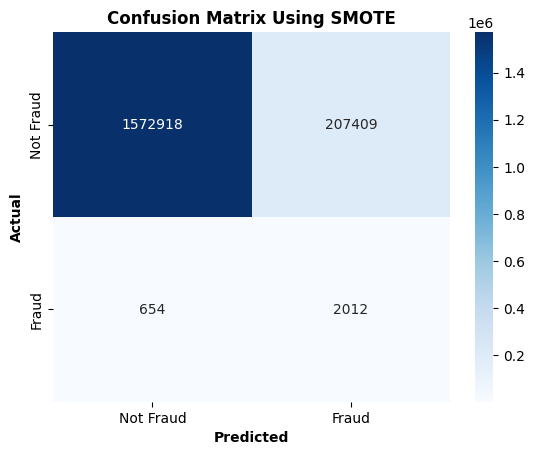

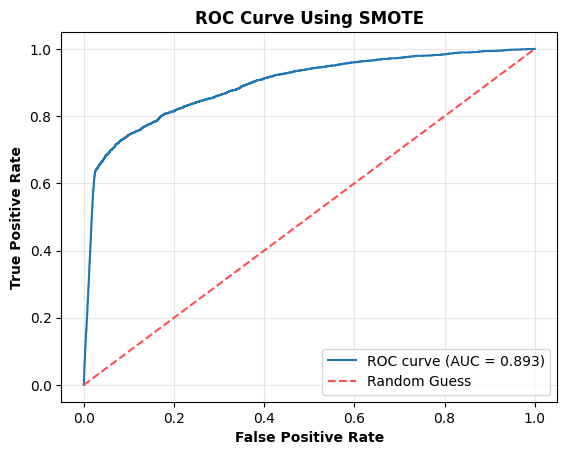

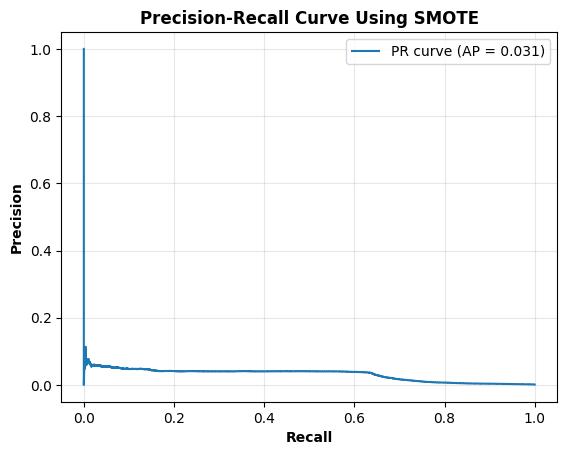

Best threshold (max F1): 0.9107
Precision at best threshold: 0.0409
Recall at best threshold: 0.4880
F1 at best threshold: 0.0756

=== Model A: SMOTE (tuned threshold) ===
              precision    recall  f1-score   support

           0       1.00      0.98      0.99   1780327
           1       0.04      0.49      0.08      2666

    accuracy                           0.98   1782993
   macro avg       0.52      0.74      0.53   1782993
weighted avg       1.00      0.98      0.99   1782993


=== Model B: class_weight = 'balanced' (threshold = 0.5) ===
              precision    recall  f1-score   support

           0       1.00      0.82      0.90   1780327
           1       0.01      0.82      0.01      2666

    accuracy                           0.82   1782993
   macro avg       0.50      0.82      0.46   1782993
weighted avg       1.00      0.82      0.90   1782993

ROC-AUC: 0.8966533614595867
PR-AUC: 0.032026466275570216


In [10]:
# Step 5: Evaluation

# --- Model A: SMOTE ---
print("=== Model A: SMOTE (threshold = 0.5) ===")
print(classification_report(y_test, y_pred_smote))
print("Accuracy:", accuracy_score(y_test, y_pred_smote))
print("F1 Score:", f1_score(y_test, y_pred_smote), "\n")

auc_score_smote = roc_auc_score(y_test, y_proba_smote)
pr_auc_smote = average_precision_score(y_test, y_proba_smote)
print("ROC-AUC: ", auc_score_smote)
print("PR-AUC: ", pr_auc_smote, "\n")

# Confusion matrix for model A
cm_smote = confusion_matrix(y_test, y_pred_smote)
sns.heatmap(cm_smote, annot = True, fmt = "d", cmap = "Blues",
            xticklabels = ["Not Fraud", "Fraud"], yticklabels = ["Not Fraud", "Fraud"]
            )
plt.title("Confusion Matrix Using SMOTE", fontweight = "bold")
plt.xlabel("Predicted", fontweight = "bold")
plt.ylabel("Actual", fontweight = "bold")
plt.show()

# ROC/AUC curve for model A
fpr, tpr, _ = roc_curve(y_test, y_proba_smote)
plt.plot(fpr, tpr, label = f"ROC curve (AUC = {auc_score_smote:.3f})")
plt.plot([0, 1], [0, 1], linestyle = "--", color = "#FF4D53", label = "Random Guess")
plt.xlabel("False Positive Rate", fontweight = "bold")
plt.ylabel("True Positive Rate", fontweight = "bold")
plt.title("ROC Curve Using SMOTE", fontweight = "bold")
plt.legend()
plt.grid(True, alpha = 0.3)
plt.show()

# Precision-Recall curve using SMOTE
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba_smote)
plt.plot(recalls, precisions, label = f"PR curve (AP = {pr_auc_smote:.3f})")
plt.xlabel("Recall", fontweight = "bold")
plt.ylabel("Precision", fontweight = "bold")
plt.title("Precision-Recall Curve Using SMOTE", fontweight = "bold")
plt.legend()
plt.grid(True, alpha = 0.3)
plt.show()

# Threshold tuning for model A
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
best_idx = f1_scores.argmax()
best_threshold = thresholds[best_idx]

print(f"Best threshold (max F1): {best_threshold:.4f}")
print(f"Precision at best threshold: {precisions[best_idx]:.4f}")
print(f"Recall at best threshold: {recalls[best_idx]:.4f}")
print(f"F1 at best threshold: {f1_scores[best_idx]:.4f}\n")

y_pred_tuned_smote = (y_proba_smote >= best_threshold).astype(int)
print("=== Model A: SMOTE (tuned threshold) ===")
print(classification_report(y_test, y_pred_tuned_smote))

# --- Model B: class_weight = "balanced" ---
print("\n=== Model B: class_weight = 'balanced' (threshold = 0.5) ===")
print(classification_report(y_test, y_pred_balanced))

auc_balanced = roc_auc_score(y_test, y_proba_balanced)
pr_auc_balanced = average_precision_score(y_test, y_proba_balanced)
print("ROC-AUC:", auc_balanced)
print("PR-AUC:", pr_auc_balanced)


## 6. Results & Conclusions

Fraud accounts for approximately 0.15% of transactions, which shaped every decision in this notebook. EDA identified two meaningful predictors: fraud rate rises sharply with transaction amount (0.1% below $250 to over 12% between $2,000 – $5,000) and varies widely by merchant category, both of which were engineered into features (`amount_log`, `mcc_risk_tier`). Other hypothesized predictors — account age, PIN recency, cardholder age — showed no relationship to fraud and were excluded.

SMOTE and `class_weight = "balanced"` produced nearly identical results (PR-AUC of 0.031 vs. 0.032), indicating the imbalance-handling technique was not the limiting factor. ROC-AUC (~0.89 – 0.90) looked strong, but PR-AUC (~0.03) revealed that most flagged transactions are false positives at any practical threshold — a reminder that ROC-AUC can be misleading under severe imbalance. Threshold tuning raised F1 from 0.019 to 0.076, at the cost of recall (0.75 → 0.49).

**Interpretation:** Since both imbalance strategies plateaued at the same ceiling, the limitation likely lies in the model itself — logistic regression's linear boundary may not capture the sharp, threshold-like fraud patterns found in EDA — rather than in how imbalance was handled.

**Limitations:** Precision is inherently constrained by fraud's rarity; `mcc_risk_tier` was built using full-dataset fraud rates (mild leakage); and no hyperparameter tuning was performed.

**Considerations:** Non-linear models (Random Forest, XGBoost) may better capture threshold-like fraud patterns; `mcc_risk_tier` could be recomputed on training data only to remove the leakage; and threshold selection could be based on the real-world costs of false positives vs. false negatives rather than F1 alone.
